# Segmentación de clientes de tarjetas de crédito

## 01 — Preparación y análisis exploratorio

Este notebook explora, limpia y prepara los datos que serán utilizados
posteriormente para la segmentación de clientes.

### Objetivos

- Comprender la estructura y calidad de los datos.
- Analizar distribuciones, asimetrías y valores extremos.
- Examinar relaciones entre variables.
- Resolver valores faltantes y eliminar variables no informativas para el clustering.
- Generar una base procesada conservando las unidades originales.

In [2]:
# Cálculo numérico
import numpy as np 

# Manipulación y análisis de datos tabulares
import pandas as pd         

# Visualización y personalización de gráficos     
import matplotlib.pyplot as plt  

# Visualizaciones estadísticas
import seaborn as sns            

## 1. Carga e inspección inicial


In [17]:
data_path = "../data/raw/CC GENERAL.csv"

df = pd.read_csv(data_path)

df.head().T


,0,1,2,3,4
CUST_ID,C10001,C10002,C10003,C10004,C10005
BALANCE,40.900749,3202.467416,2495.148862,1666.670542,817.714335
BALANCE_FREQUENCY,0.818182,0.909091,1.0,0.636364,1.0
PURCHASES,95.4,0.0,773.17,1499.0,16.0
ONEOFF_PURCHASES,0.0,0.0,773.17,1499.0,16.0
INSTALLMENTS_PURCHASES,95.4,0.0,0.0,0.0,0.0
CASH_ADVANCE,0.0,6442.945483,0.0,205.788017,0.0
PURCHASES_FREQUENCY,0.166667,0.0,1.0,0.083333,0.083333
ONEOFF_PURCHASES_FREQUENCY,0.0,0.0,1.0,0.083333,0.083333
PURCHASES_INSTALLMENTS_FREQUENCY,0.083333,0.0,0.0,0.0,0.0


In [4]:
df.shape


(8950, 18)

El conjunto de datos contiene **8.950 clientes y 18 variables**. Cada fila representa un cliente de tarjeta de crédito.


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [25]:
df.describe().T




,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


## 2. Calidad de los datos

Se revisan registros duplicados, unicidad del identificador y valores faltantes antes de realizar cualquier modificación.


In [7]:
print(f"Registros duplicados: {df.duplicated().sum()}")
print(f"Clientes únicos: {df['CUST_ID'].nunique()}")


Registros duplicados: 0
Clientes únicos: 8950


In [8]:
missing = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": df.isna().mean() * 100
})

missing[missing["Nulos"] > 0]


,Nulos,Porcentaje
CREDIT_LIMIT,1,0.011173
MINIMUM_PAYMENTS,313,3.497207


In [9]:
df[["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]].agg(
    ["mean", "median"]
).T


,mean,median
CREDIT_LIMIT,4494.449450,3000.000000
MINIMUM_PAYMENTS,864.206542,312.343947


Se observan valores faltantes únicamente en `CREDIT_LIMIT` y `MINIMUM_PAYMENTS`, con una proporción baja respecto del total de observaciones.

Ambas variables presentan distribuciones asimétricas y valores elevados que pueden influir en la media. Por esta razón, se utiliza la **mediana** como una imputación simple y robusta.

No se crea un indicador adicional de ausencia porque la documentación disponible no entrega evidencia de que estos valores faltantes representen por sí mismos un comportamiento particular del cliente.


In [30]:
missing_features = ["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]

df[missing_features] = df[missing_features].fillna(
    df[missing_features].median()
)

print(f"Valores faltantes restantes: {df.isna().sum().sum()}")


Valores faltantes restantes: 0


`CUST_ID` es un identificador único y no representa una característica del comportamiento del cliente. Por lo tanto, se elimina antes del análisis y no se utilizará en la segmentación.


In [31]:
df.drop(columns="CUST_ID", inplace=True)


## 3. Distribuciones, asimetría y valores extremos

Se inspeccionan las distribuciones para detectar variables fuertemente asimétricas y observaciones extremas. En este notebook solo se realiza el diagnóstico; las transformaciones necesarias para el clustering se definirán en el notebook de modelamiento.


In [32]:
print(df.describe().T.round(2).to_markdown())

|                                  |   count |    mean |     std |   min |     25% |     50% |     75% |     max |
|:---------------------------------|--------:|--------:|--------:|------:|--------:|--------:|--------:|--------:|
| BALANCE                          |    8950 | 1564.47 | 2081.53 |  0    |  128.28 |  873.39 | 2054.14 | 19043.1 |
| BALANCE_FREQUENCY                |    8950 |    0.88 |    0.24 |  0    |    0.89 |    1    |    1    |     1   |
| PURCHASES                        |    8950 | 1003.2  | 2136.63 |  0    |   39.64 |  361.28 | 1110.13 | 49039.6 |
| ONEOFF_PURCHASES                 |    8950 |  592.44 | 1659.89 |  0    |    0    |   38    |  577.4  | 40761.2 |
| INSTALLMENTS_PURCHASES           |    8950 |  411.07 |  904.34 |  0    |    0    |   89    |  468.64 | 22500   |
| CASH_ADVANCE                     |    8950 |  978.87 | 2097.16 |  0    |    0    |    0    | 1113.82 | 47137.2 |
| PURCHASES_FREQUENCY              |    8950 |    0.49 |    0.4  |  0    |    0.

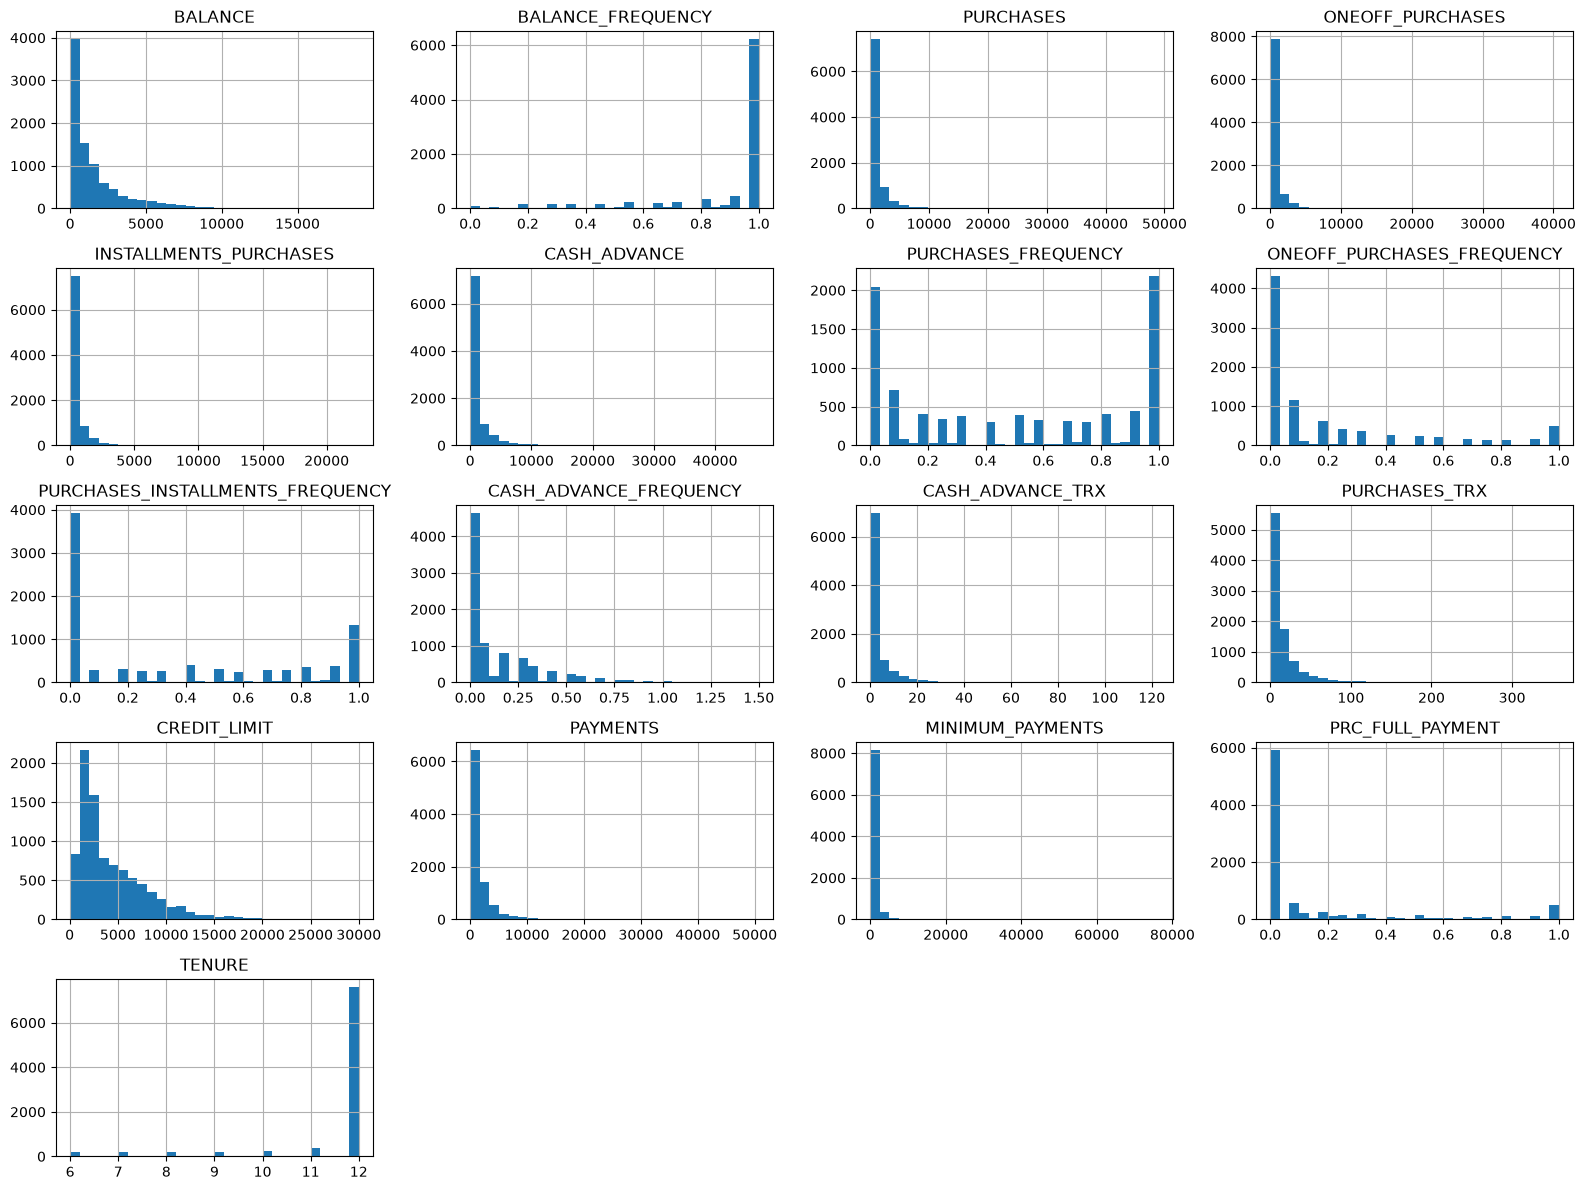

In [ ]:
df.hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()

plt.savefig(
    "../figures/feature_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


Varias variables presentan asimetría positiva y valores extremos, especialmente las asociadas a compras, adelantos de efectivo, pagos y saldos.

Estas características pueden afectar métodos basados en distancias. La conveniencia de aplicar transformaciones y estandarización se evaluará posteriormente según la naturaleza de cada variable y los requisitos del método de segmentación.


In [13]:
skewness = df.skew().sort_values(ascending=False)

skewness


MINIMUM_PAYMENTS                    13.852446
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522636
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

In [33]:
print(skewness.round(2).to_markdown())

|                                  |     0 |
|:---------------------------------|------:|
| MINIMUM_PAYMENTS                 | 13.85 |
| ONEOFF_PURCHASES                 | 10.05 |
| PURCHASES                        |  8.14 |
| INSTALLMENTS_PURCHASES           |  7.3  |
| PAYMENTS                         |  5.91 |
| CASH_ADVANCE_TRX                 |  5.72 |
| CASH_ADVANCE                     |  5.17 |
| PURCHASES_TRX                    |  4.63 |
| BALANCE                          |  2.39 |
| PRC_FULL_PAYMENT                 |  1.94 |
| CASH_ADVANCE_FREQUENCY           |  1.83 |
| ONEOFF_PURCHASES_FREQUENCY       |  1.54 |
| CREDIT_LIMIT                     |  1.52 |
| PURCHASES_INSTALLMENTS_FREQUENCY |  0.51 |
| PURCHASES_FREQUENCY              |  0.06 |
| BALANCE_FREQUENCY                | -2.02 |
| TENURE                           | -2.94 |


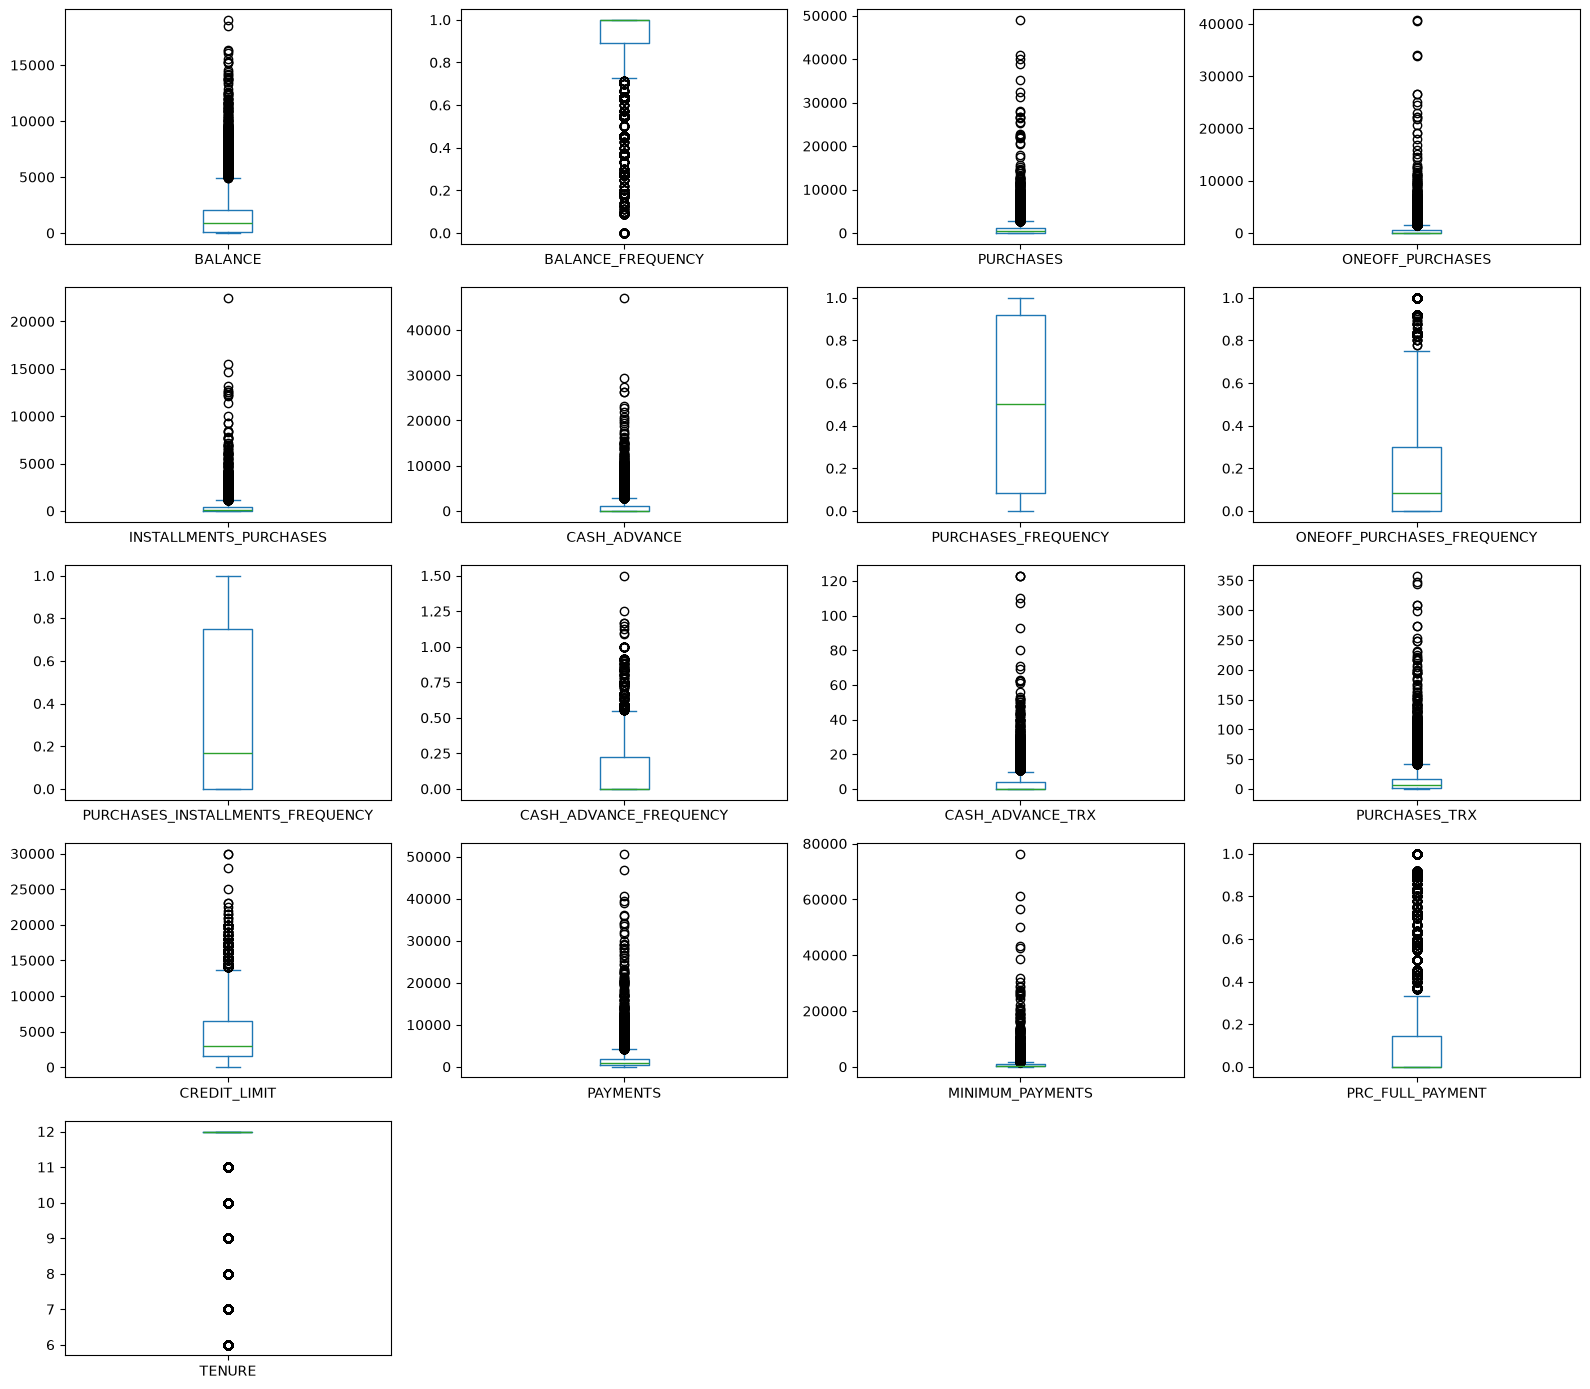

In [20]:
df.plot(
    kind="box",
    subplots=True,
    layout=(5, 4),
    figsize=(16, 14),
    sharex=False,
    sharey=False
)

plt.tight_layout()

plt.savefig(
    "../figures/boxplots.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


Los boxplots exponen presencia de numerosos valores extremos, especialmente en variables monetarias y transaccionales.

## 4. Correlaciones


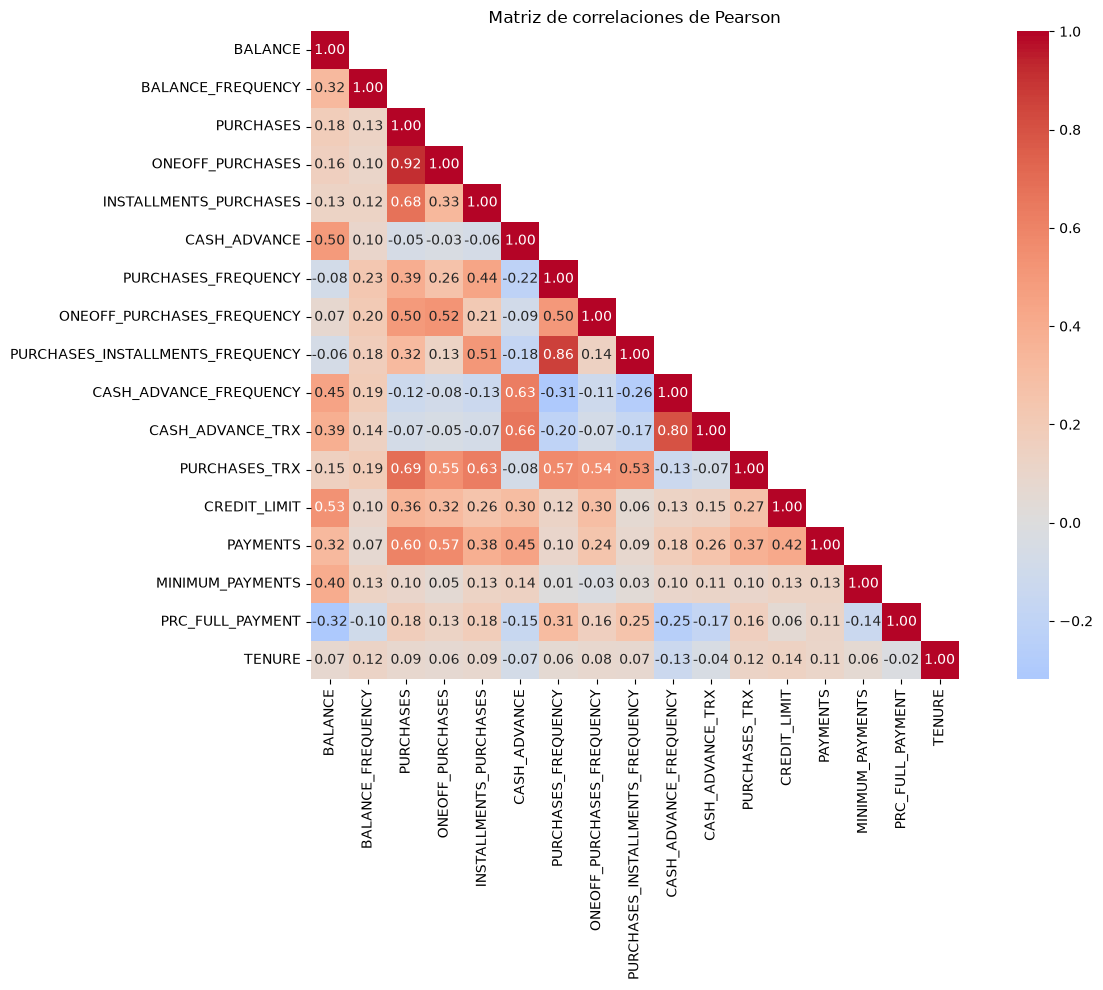

In [15]:
corr = df.corr(method="pearson")

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Matriz de correlaciones de Pearson")
plt.tight_layout()
plt.show()


La matriz de correlaciones muestra grupos de variables relacionadas, particularmente entre medidas de compras y entre variables asociadas a adelantos de efectivo.

Estas relaciones sugieren cierta redundancia en la información, lo que podrá estudiarse posteriormente mediante técnicas como PCA.


## 5. Guardado de la base procesada

La base se guarda sin el identificador, sin valores faltantes y manteniendo las variables en sus unidades originales. Las transformaciones y el escalamiento se realizarán en el notebook de segmentación.


In [16]:
processed_path = "../data/processed/customers_processed.csv"

df.to_csv(processed_path, index=False)

print(f"Base procesada guardada en: {processed_path}")
print(f"Dimensiones finales: {df.shape}")


Base procesada guardada en: ../data/processed/customers_processed.csv
Dimensiones finales: (8950, 17)


### Resultado

La base procesada queda lista para la etapa de modelamiento:

- sin registros duplicados;
- sin valores faltantes;
- sin `CUST_ID`;
- con las variables todavía en una escala interpretable;
- sin transformaciones ni estandarización aplicadas.
